In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=markers,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(12)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.61890,0.23932,14.40724,0.60920,3.580369e-108,6.286828e-106
1,ANKRD55,0.55384,0.14907,18.15077,0.56983,6.599844e-73,5.871235e-71
2,FHIT,0.51857,0.61805,9.98009,0.77473,3.305650e-282,3.695496e-279
3,TSHZ2,0.48540,0.32393,6.24771,0.63679,6.612532e-118,1.327971e-115
4,TCEA3,0.48253,0.21112,7.64557,0.59006,2.671241e-75,2.509470e-73
5,AC005842.1,0.47176,0.16116,8.76196,0.57096,8.924564e-64,6.520959e-62
6,CHRM3-AS2,0.46413,0.38114,7.60798,0.66321,7.806746e-146,2.218836e-143
7,CMTM8,0.43859,0.30379,4.91709,0.61914,1.037609e-85,1.298483e-83
8,EPHX2,0.43070,0.38920,6.87740,0.66277,6.659238e-138,1.731299e-135
9,DPYSL4,0.42810,0.10234,19.18164,0.54824,3.127083e-51,1.659432e-49


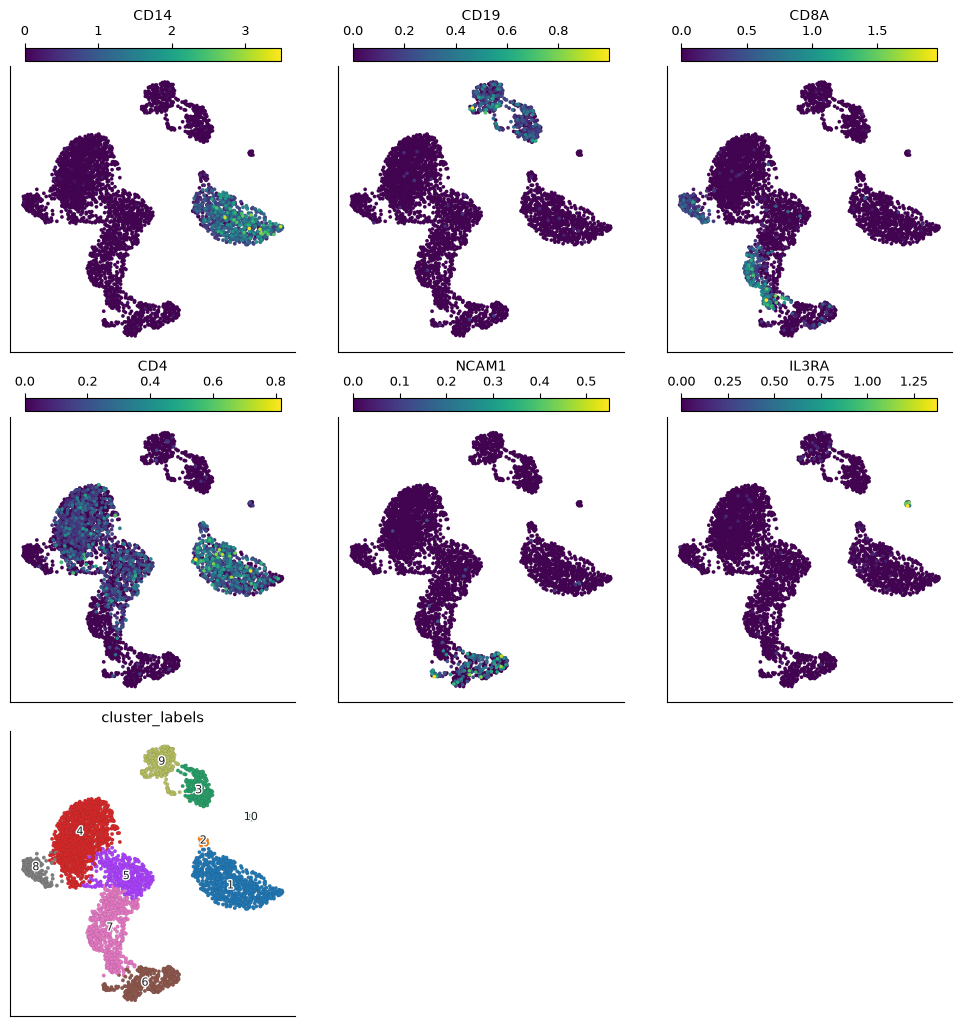

In [3]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA", clusters],
    n_columns=3,
    sort_values=True,
    legend_loc="on_data"
)

In [4]:
panel_genes = ["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA"]
panel_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
panel_stats = panel_markers[panel_markers["feature_name"].isin(panel_genes)]
panel_best = (
    panel_stats.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")
    .reindex(panel_genes)[["group_id", "score", "frac_exp", "auc"]]
    .round(2)
    .reset_index()
)
panel_best

,feature_name,group_id,score,frac_exp,auc
0,CD14,1,0.92,0.95,0.98
1,CD19,9,0.54,0.61,0.78
2,CD8A,8,0.51,0.87,0.88
3,CD4,1,0.33,0.75,0.77
4,NCAM1,6,0.76,0.40,0.70
5,IL3RA,10,0.81,1.00,1.00


In [5]:
proposed_labels = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "T cells",
    "8": "T cells",
    "9": "B cells",
    "10": "pDC-like cells",
}
pd.Series(proposed_labels, name="proposed_cell_type")
assert set(proposed_labels) == {str(value) for value in np.unique(cluster_values)}

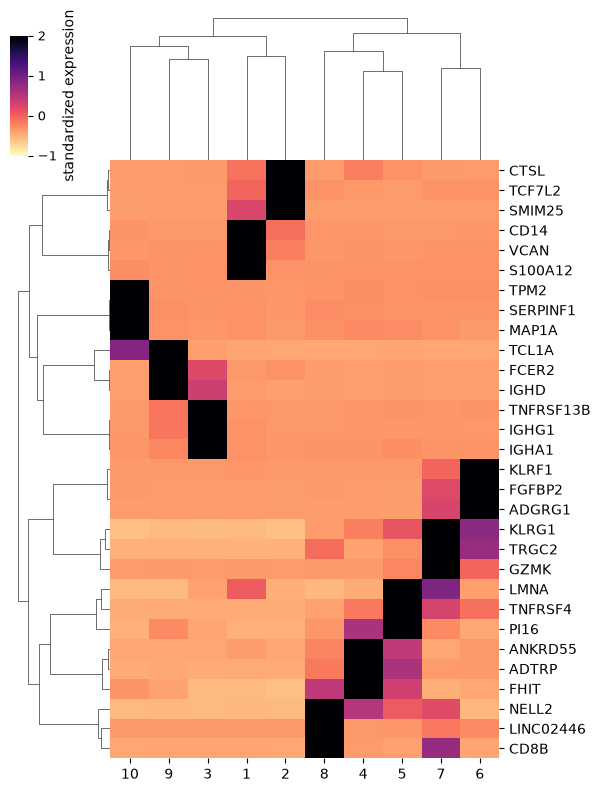

In [6]:
ds.plots.marker_heatmap(
    marker=markers,
    topn=3,
    figsize=(6, 8),
)

In [7]:
heatmap_genes = [
    "CD14", "VCAN", "S100A12", "CTSL", "TCF7L2", "SMIM25", "FCGR3A", "FCER2",
    "IGHD", "IGHA1", "IGHG1", "TNFRSF13B", "KLRF1", "FGFBP2", "GNLY", "XCL1",
    "XCL2", "KLRC1", "GZMK", "TRGC2", "KLRG1", "CD8A", "LINC02446",
    "CD8B", "CD3D", "CD3E", "ADTRP", "ANKRD55", "FHIT", "TSHZ2", "TNFRSF4",
    "LMNA", "NPDC1", "PI16", "NKG7", "TCL1A", "NELL2", "LILRA4", "IL3RA",
    "SERPINF1", "ADGRG1", "AKR1C3", "CCR7", "IL7R", "CD27",
]
heatmap_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
heatmap_hits = heatmap_markers[heatmap_markers["feature_name"].isin(heatmap_genes)]
heatmap_table = (
    heatmap_hits.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .sort_values("score", ascending=False)
)
heatmap_table["proposed_identity"] = (
    heatmap_table["group_id"].astype(str).map(proposed_labels)
)
heatmap_table[["feature_name", "group_id", "score", "frac_exp", "proposed_identity"]]

,feature_name,group_id,score,frac_exp,proposed_identity
0,S100A12,1,0.95617,0.93994,CD14 monocytes
1,VCAN,1,0.92713,0.96648,CD14 monocytes
2,CD14,1,0.92068,0.95251,CD14 monocytes
167690,KLRF1,6,0.87437,0.96865,NK cells
67076,IGHA1,3,0.85591,0.72385,B cells
67077,TNFRSF13B,3,0.83965,0.73222,B cells
301843,SERPINF1,10,0.82985,1.00000,pDC-like cells
201228,GZMK,7,0.82709,0.71558,T cells
301845,LILRA4,10,0.81141,1.00000,pDC-like cells
167691,FGFBP2,6,0.81077,0.92163,NK cells


In [8]:
neg_genes = ["CD3D", "CD3E", "CD4", "MS4A1", "CD14"]
neg_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
neg_stats = neg_markers[neg_markers["feature_name"].isin(neg_genes)]
neg_stats[["group_id", "feature_name", "score", "frac_exp", "auc"]].sort_values(
    ["feature_name", "group_id"]
)

,group_id,feature_name,score,frac_exp,auc
2,1,CD14,0.92068,0.95251,0.97550
334922,10,CD14,0.00394,0.06667,0.43380
62292,2,CD14,0.04880,0.32000,0.54196
100519,3,CD14,0.00342,0.01255,0.40632
134039,4,CD14,0.00445,0.01692,0.37439
167639,5,CD14,0.00277,0.00461,0.39742
201136,6,CD14,0.00439,0.01567,0.40574
234718,7,CD14,0.00331,0.01087,0.39688
268135,8,CD14,0.00478,0.02649,0.41453
301797,9,CD14,0.00345,0.01562,0.40723


In [9]:
anchor_genes = ["NKG7", "GNLY", "KLRF1", "FGFBP2", "CD8A", "CD8B"]
anchor_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
anchor_stats = anchor_markers[anchor_markers["feature_name"].isin(anchor_genes)]
anchor_stats[["group_id", "feature_name", "score", "frac_exp", "auc"]].sort_values(
    ["feature_name", "group_id"]
)

,group_id,feature_name,score,frac_exp,auc
33363,1,CD8A,0.00633,0.01117,0.43812
334779,10,CD8A,0.00530,0.06667,0.47380
66787,2,CD8A,0.00331,0.00000,0.44379
100478,3,CD8A,0.00446,0.00837,0.44460
133944,4,CD8A,0.00721,0.01128,0.42629
167356,5,CD8A,0.01412,0.02304,0.44969
200042,6,CD8A,0.05434,0.11285,0.49807
201235,7,CD8A,0.38830,0.42935,0.69144
234769,8,CD8A,0.51247,0.86755,0.88361
301770,9,CD8A,0.00416,0.00781,0.44406


In [10]:
guard_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
best_cluster = (
    guard_markers[guard_markers["feature_name"].isin(
        ["NKG7", "GNLY", "KLRF1", "FGFBP2", "CD8A", "CD8B", "IL3RA",
         "LILRA4", "IGHD", "IGHA1", "CD14", "CDKN1C", "TCF7L2", "MS4A1",
         "CD27", "CCR7", "GZMK", "PRF1"]
    )]
    .sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")["group_id"]
    .astype(str)
    .to_dict()
)
assert best_cluster["NKG7"] == "6"
assert best_cluster["GNLY"] == "6"
assert best_cluster["KLRF1"] == "6"
assert best_cluster["FGFBP2"] == "6"
assert best_cluster["CD8A"] == "8"
assert best_cluster["CD8B"] == "8"
assert best_cluster["CD27"] == "8"
assert best_cluster["CCR7"] in {"4", "8"}
assert best_cluster["GZMK"] == "7"
assert best_cluster["PRF1"] == "6"
assert best_cluster["IL3RA"] == "10"
assert best_cluster["LILRA4"] == "10"
assert best_cluster["IGHD"] == "9"
assert best_cluster["IGHA1"] == "3"
assert best_cluster["CD14"] == "1"
assert best_cluster["CDKN1C"] == "2"
assert best_cluster["TCF7L2"] == "2"
assert best_cluster["MS4A1"] in {"3", "9"}
best_cluster

{'CD14': '1',
 'KLRF1': '6',
 'IGHA1': '3',
 'GZMK': '7',
 'LILRA4': '10',
 'FGFBP2': '6',
 'IL3RA': '10',
 'IGHD': '9',
 'TCF7L2': '2',
 'GNLY': '6',
 'CDKN1C': '2',
 'PRF1': '6',
 'CD8B': '8',
 'NKG7': '6',
 'CD8A': '8',
 'MS4A1': '3',
 'CCR7': '4',
 'CD27': '8'}

In [11]:
final_labels = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "memory B cells",
    "4": "T cells",
    "5": "CD4+ T cells",
    "6": "NK cells",
    "7": "CD8+ T cells",
    "8": "naive CD8 T cells",
    "9": "naive B cells",
    "10": "pDC-like cells",
}
observed = {str(value) for value in np.unique(cluster_values)}
assert observed == set(final_labels)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_type[analysis_cells] = [final_labels[str(value)] for value in cluster_values]
ds.cells.insert("reviewed_cell_type", cell_type, overwrite=True)
pd.Series(cell_type[analysis_cells]).value_counts()

T cells              1241
CD14 monocytes        716
CD8+ T cells          552
CD4+ T cells          434
NK cells              319
naive B cells         256
memory B cells        239
naive CD8 T cells     151
monocytes              25
pDC-like cells         15
Name: count, dtype: int64

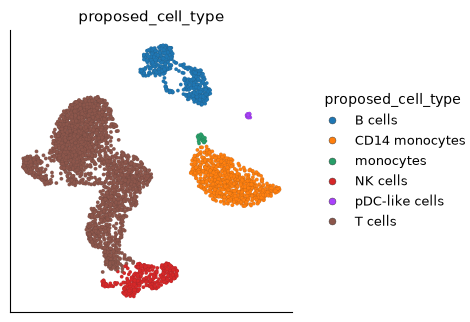

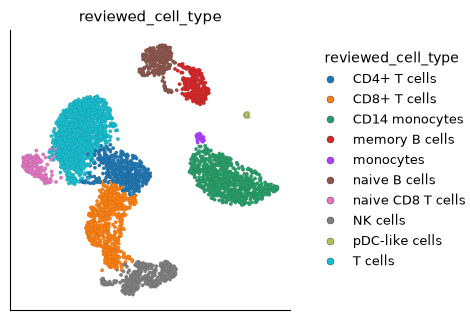

In [12]:
initial_cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
initial_cell_type[analysis_cells] = [proposed_labels[str(value)] for value in cluster_values]
ds.cells.insert("proposed_cell_type", initial_cell_type, overwrite=True)
ds.plots.embedding(
    layout=run["umap"],
    color_by="proposed_cell_type",
    legend_loc="right",
)

ds.plots.embedding(
    layout=run["umap"],
    color_by="reviewed_cell_type",
    legend_loc="right",
)